Порядок работы в notebook
1. Загрузить датасет
pd.read_csv, посмотреть df.head(), df.shape, df.dtypes
2. Описать датасет
Что за данные, сколько строк, какие поля
3. Почистить данные
df.isna().sum(), убрать NaN, проверить типы
4. Descriptive statistics
df.describe(), mean/median/std для 4 числовых полей
5. Простые графики
4 графика, 3 разных типа
6. Подробный анализ
4 сравнения — тут уже начинаешь замечать интересные связи
7. Трансформация
Добавить 1-2 новых колонки
8. Гипотезы
Вот здесь — после того как посмотрели на данные, выдвигаете 2 гипотезы и проверяете их графиками/статистикой
9. Discussion
После каждого блока пишете пару предложений что увидели

Flight Price Analysis
Kazykina Sofya & Gainullina Amina

In [109]:
%matplotlib inline
import pandas as pd
import streamlit as st
import matplotlib.pyplot as plt
import seaborn as sns


In [110]:
df = pd.read_csv('Clean_Dataset.csv')
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [111]:
# цена за час полёта
df['price_per_hour'] = df['price'] / df['duration']

df[['airline', 'duration', 'price', 'price_per_hour']].head(10)

,airline,duration,price,price_per_hour
0,SpiceJet,2.17,5953,2743.317972
1,SpiceJet,2.33,5953,2554.935622
2,AirAsia,2.17,5956,2744.700461
3,Vistara,2.25,5955,2646.666667
4,Vistara,2.33,5955,2555.793991
5,Vistara,2.33,5955,2555.793991
6,Vistara,2.08,6060,2913.461538
7,Vistara,2.17,6060,2792.626728
8,GO_FIRST,2.17,5954,2743.778802
9,GO_FIRST,2.25,5954,2646.222222


In [112]:
df.tail()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,price_per_hour
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265,6871.527778
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105,7399.712092
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099,5719.378163
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585,8158.500000
300152,300152,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,81585,8093.750000


Датасет содержит информацию о рейсах в Индии: авиакомпания, маршрут,
время вылета и прилёта, количество пересадок, класс и цена билета.

Числовые поля: price, duration, days_left, num_stops
Категориальные поля: airline, source_city, destination_city, departure_time, class

In [113]:
df.shape

(300153, 13)

In [114]:
df.dtypes

Unnamed: 0            int64
airline                 str
flight                  str
source_city             str
departure_time          str
stops                   str
arrival_time            str
destination_city        str
class                   str
duration            float64
days_left             int64
price                 int64
price_per_hour      float64
dtype: object

In [115]:
df = pd.read_csv("Clean_Dataset.csv", index_col=0)
df.tail()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585
300152,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,81585


убрала колонку unnamed

начинаю очистку данных

In [116]:
df = pd.read_csv("Clean_Dataset.csv", index_col=0)

In [117]:
print("Размер датасета:", df.shape)
print("\nПропущенные значения:")
print(df.isna().sum())
print("\nТипы данных:")
print(df.dtypes)

Размер датасета: (300153, 11)

Пропущенные значения:
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

Типы данных:
airline                 str
flight                  str
source_city             str
departure_time          str
stops                   str
arrival_time            str
destination_city        str
class                   str
duration            float64
days_left             int64
price                 int64
dtype: object


In [118]:
stops_map = {"zero": 0, "one": 1, "two": 2, "three": 3, "four": 4}
df["num_stops"] = df["stops"].map(stops_map)
df = df.drop(columns=["stops", "flight"])
df


,airline,source_city,departure_time,arrival_time,destination_city,class,duration,days_left,price,num_stops
0,SpiceJet,Delhi,Evening,Night,Mumbai,Economy,2.17,1,5953,0.0
1,SpiceJet,Delhi,Early_Morning,Morning,Mumbai,Economy,2.33,1,5953,0.0
2,AirAsia,Delhi,Early_Morning,Early_Morning,Mumbai,Economy,2.17,1,5956,0.0
3,Vistara,Delhi,Morning,Afternoon,Mumbai,Economy,2.25,1,5955,0.0
4,Vistara,Delhi,Morning,Morning,Mumbai,Economy,2.33,1,5955,0.0
...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,Chennai,Morning,Evening,Hyderabad,Business,10.08,49,69265,1.0
300149,Vistara,Chennai,Afternoon,Night,Hyderabad,Business,10.42,49,77105,1.0
300150,Vistara,Chennai,Early_Morning,Night,Hyderabad,Business,13.83,49,79099,1.0
300151,Vistara,Chennai,Early_Morning,Evening,Hyderabad,Business,10.00,49,81585,1.0


In [119]:
# Удаляем строки, где num_stops is NaN
df = df.dropna(subset=['num_stops'])

df['num_stops'] = df['num_stops'].astype(int)

df[['num_stops']].head()

,num_stops
0,0
1,0
2,0
3,0
4,0


In [120]:
df[['price', 'duration', 'days_left', 'num_stops']].agg(['mean', 'median', 'std'])

,price,duration,days_left,num_stops
mean,21203.494888,12.077627,26.059104,0.874492
median,7410.000000,11.170000,26.000000,1.000000
std,22855.499104,7.150199,13.552087,0.331294


<Axes: xlabel='price', ylabel='Count'>

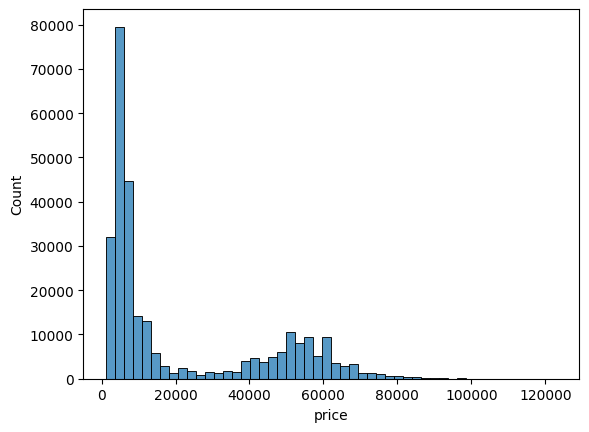

In [121]:
sns.histplot(df['price'], bins=50)

In [122]:
print("Новые колонки:")
print(df.dtypes)

Новые колонки:
airline                 str
source_city             str
departure_time          str
arrival_time            str
destination_city        str
class                   str
duration            float64
days_left             int64
price                 int64
num_stops             int64
dtype: object


Датасет не содержал пропущенных значений. Убрали колонку `Unnamed: 0` 
при загрузке, колонку `flight` (номер рейса — не несёт аналитической ценности) 
и преобразовали `stops` из текстового формата в числовой (`num_stops`).

In [123]:
df.info()

<class 'pandas.DataFrame'>
Index: 286867 entries, 0 to 300152
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           286867 non-null  str    
 1   source_city       286867 non-null  str    
 2   departure_time    286867 non-null  str    
 3   arrival_time      286867 non-null  str    
 4   destination_city  286867 non-null  str    
 5   class             286867 non-null  str    
 6   duration          286867 non-null  float64
 7   days_left         286867 non-null  int64  
 8   price             286867 non-null  int64  
 9   num_stops         286867 non-null  int64  
dtypes: float64(1), int64(3), str(6)
memory usage: 36.4 MB


In [124]:
df.groupby("airline")["price"].mean()   
df.groupby("class")["price"].median() 

class
Business    53164.0
Economy      5632.0
Name: price, dtype: float64

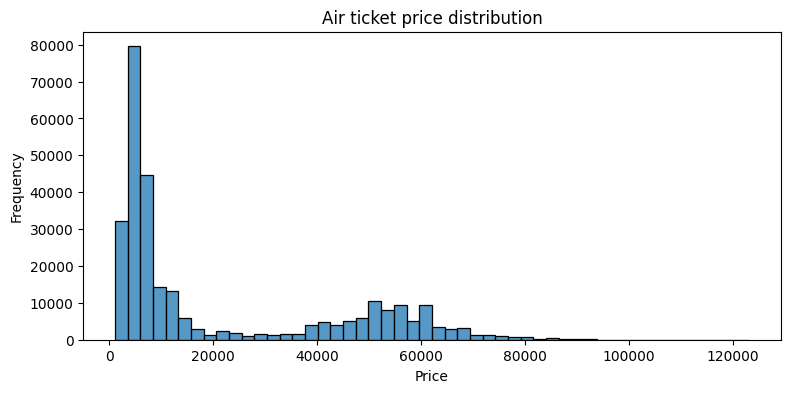

In [128]:
plt.figure(figsize=(9,4))
sns.histplot(df['price'], bins=50)
plt.title('Air ticket price distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

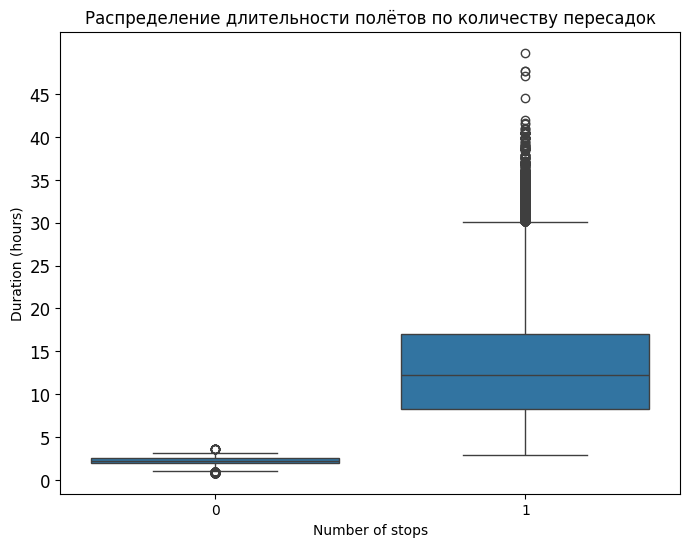

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(x='num_stops', y='duration', data=df)
plt.title('Распределение длительности полётов по количеству пересадок')
plt.xlabel('Number of stops')
plt.ylabel('Duration (hours)')
plt.yticks(fontsize=12)
max_dur = int(df['duration'].max()) + 1
plt.yticks(range(0, max_dur, 5))
plt.show()

In [127]:
print(df['duration'].mean())

12.077626670199082


boxplot цены в зависимости от количества пересадок

In [139]:
df

,airline,source_city,departure_time,arrival_time,destination_city,class,duration,days_left,price,num_stops
0,SpiceJet,Delhi,Evening,Night,Mumbai,Economy,2.17,1,5953,0
1,SpiceJet,Delhi,Early_Morning,Morning,Mumbai,Economy,2.33,1,5953,0
2,AirAsia,Delhi,Early_Morning,Early_Morning,Mumbai,Economy,2.17,1,5956,0
3,Vistara,Delhi,Morning,Afternoon,Mumbai,Economy,2.25,1,5955,0
4,Vistara,Delhi,Morning,Morning,Mumbai,Economy,2.33,1,5955,0
...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,Chennai,Morning,Evening,Hyderabad,Business,10.08,49,69265,1
300149,Vistara,Chennai,Afternoon,Night,Hyderabad,Business,10.42,49,77105,1
300150,Vistara,Chennai,Early_Morning,Night,Hyderabad,Business,13.83,49,79099,1
300151,Vistara,Chennai,Early_Morning,Evening,Hyderabad,Business,10.00,49,81585,1


<Axes: ylabel='duration'>

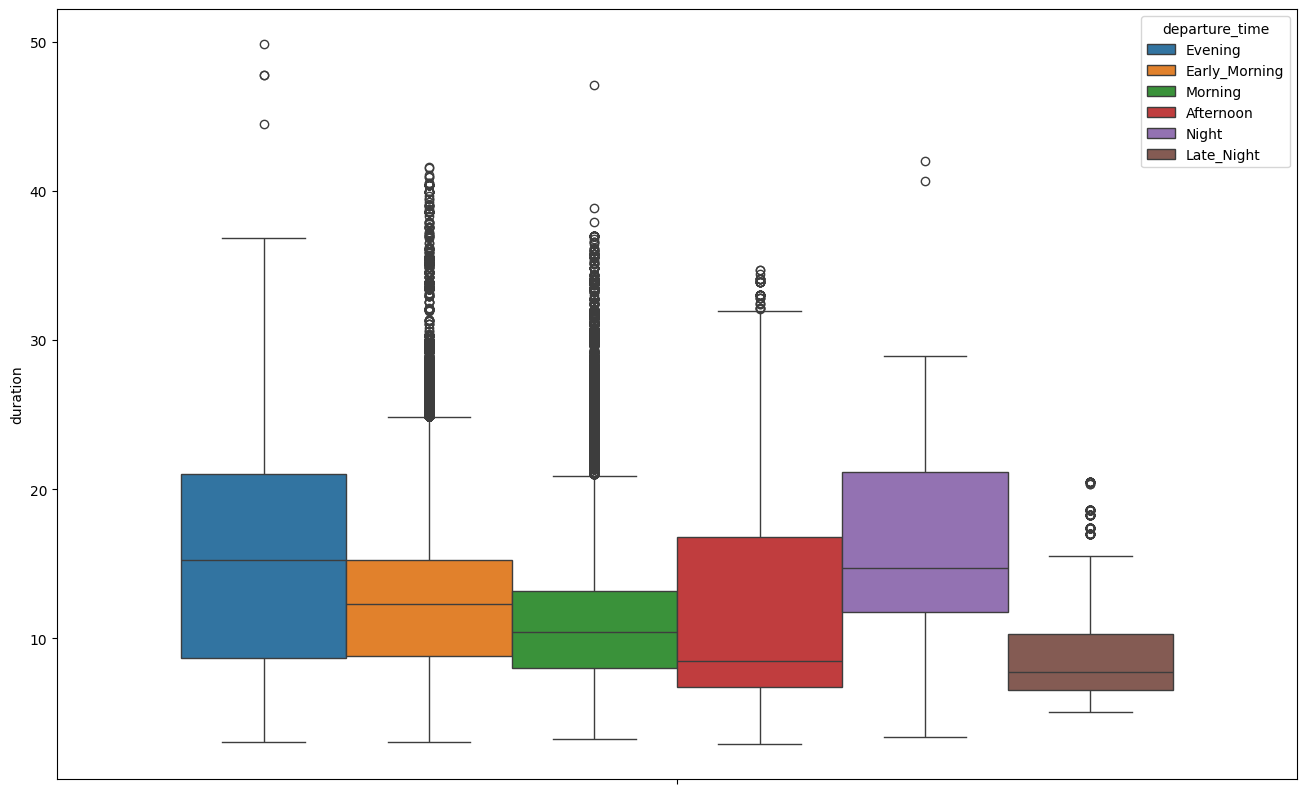

In [151]:
plt.figure(figsize=(16,10))
sns.boxplot(y='duration', data=df[df.num_stops == 1], hue="departure_time")
# plt.title('Распределение цен по количеству пересадок')
# plt.xlabel('Number of stops')
# plt.ylabel('Price')
# plt.xticks(fontsize=10)
# plt.yticks(fontsize=10)
# plt.show()

In [137]:
df.groupby("num_stops")["price"].describe()

,count,mean,std,min,25%,50%,75%,max
num_stops,,,,,,,,
0,36004.0,9375.938535,10623.008293,1105.0,2586.0,4499.0,8064.0,59573.0
1,250863.0,22900.992482,23626.066584,1105.0,5136.0,7959.0,48851.0,123071.0
